In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
train_df = pd.read_csv("//content//drive//MyDrive//ML_Files//Lab9//BBC News Train.csv")
test_df  = pd.read_csv("//content//drive//MyDrive//ML_Files//Lab9//BBC News Test.csv")

train_df.head()


,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [3]:
#Clean Text

import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove symbols & numbers
    text = re.sub(r"\s+", " ", text).strip() # remove extra spaces
    return text

train_df["clean_text"] = train_df["Text"].apply(clean_text)
test_df["clean_text"]  = test_df["Text"].apply(clean_text)


In [5]:
#Encode Categories into Numbers
label_encoder = LabelEncoder()
train_df["label"] = label_encoder.fit_transform(train_df["Category"])

print(label_encoder.classes_)


['business' 'entertainment' 'politics' 'sport' 'tech']


In [6]:
#Tokenize text
vocab_size = 10000
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["clean_text"])

#convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(train_df["clean_text"])
X_test_seq  = tokenizer.texts_to_sequences(test_df["clean_text"])


In [7]:
#Pad sequences

max_length = 250

X_train = pad_sequences(X_train_seq, maxlen=max_length, padding="post")
X_test  = pad_sequences(X_test_seq, maxlen=max_length, padding="post")


In [8]:
y = train_df["label"]

X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y, test_size=0.2, random_state=42, stratify=y
)


In [9]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

num_classes = 5  # business, tech, entertainment, sports, politics
embedding_dim = 128

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),

    LSTM(128, return_sequences=False),   # main LSTM layer

    Dropout(0.3),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(num_classes, activation="softmax")  # output for 5 categories
])

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train_split,
    y_train_split,
    validation_data=(X_val_split, y_val_split),
    epochs=8,
    batch_size=32
)


Epoch 1/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 746ms/step - accuracy: 0.2465 - loss: 1.6038 - val_accuracy: 0.3255 - val_loss: 1.5729
Epoch 2/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 482ms/step - accuracy: 0.3765 - loss: 1.5349 - val_accuracy: 0.3691 - val_loss: 1.4110
Epoch 3/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 521ms/step - accuracy: 0.4090 - loss: 1.2800 - val_accuracy: 0.4832 - val_loss: 1.2600
Epoch 4/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 495ms/step - accuracy: 0.5266 - loss: 1.0928 - val_accuracy: 0.5403 - val_loss: 1.1228
Epoch 5/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 485ms/step - accuracy: 0.6652 - loss: 0.9009 - val_accuracy: 0.5973 - val_loss: 1.0592
Epoch 6/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 557ms/step - accuracy: 0.7022 - loss: 0.7386 - val_accuracy: 0.5336 - val_loss: 1.1361
Epoch 7/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 536ms/step - accuracy: 0.7840 - loss: 0.5513 - val_accuracy: 0.5738 - val_loss: 1.0243
Epoch 8/8
38/38 ━━━━━━━━━━━━━━━━━━━━ 42s 568ms/step - accuracy: 0.7986 - loss: 0.5265 - val_accuracy: 0.

In [11]:
val_loss, val_acc = model.evaluate(X_val_split, y_val_split)
print("Validation Accuracy:", val_acc)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.5886 - loss: 1.1145
Validation Accuracy: 0.5805369019508362


In [12]:
pred_probs = model.predict(X_test)
pred_labels = pred_probs.argmax(axis=1)

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step


In [13]:
test_df["Predicted_Category"] = label_encoder.inverse_transform(pred_labels)

In [16]:
test_df.to_csv("BBC_Predictions.csv", index=False)

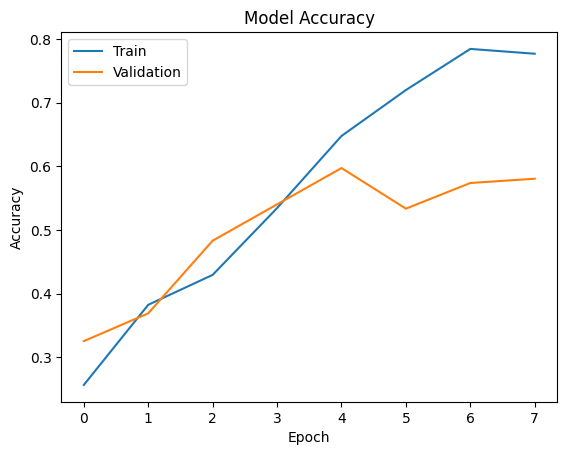

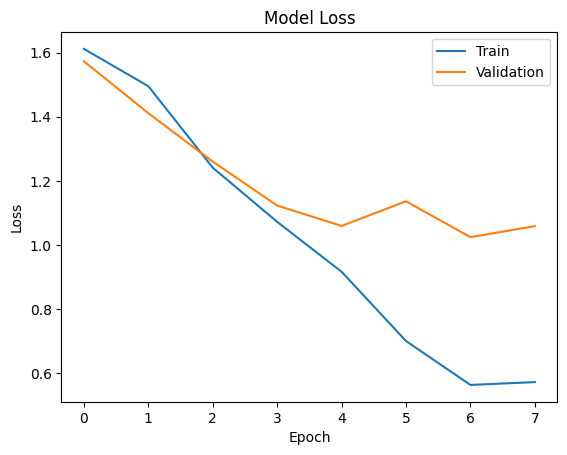

In [14]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 390ms/step


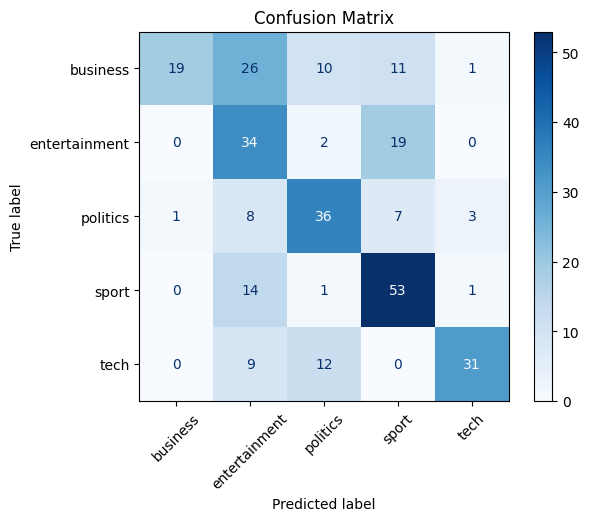

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict validation set
val_pred_prob = model.predict(X_val_split)
val_pred = val_pred_prob.argmax(axis=1)

# Create confusion matrix
cm = confusion_matrix(y_val_split, val_pred)

# Labels (business, tech, entertainment, sports, politics)
labels = label_encoder.classes_

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()
